In [2]:
import numpy as np
import pandas as pd
from scipy import signal
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

Loading data... (This may take a moment for large files)
Calculating Jitter...
--- Jitter Results ---
Mean Frequency: 350.00 MHz
RMS Jitter:     0.32 ps
Pk-Pk Jitter:   1.94 ps

Calculating Frequency Data...
--- Phase Noise Results ---
Carrier Freq:   350.00 MHz
Phase Noise @ 1MHz: -6.02 dBc/Hz


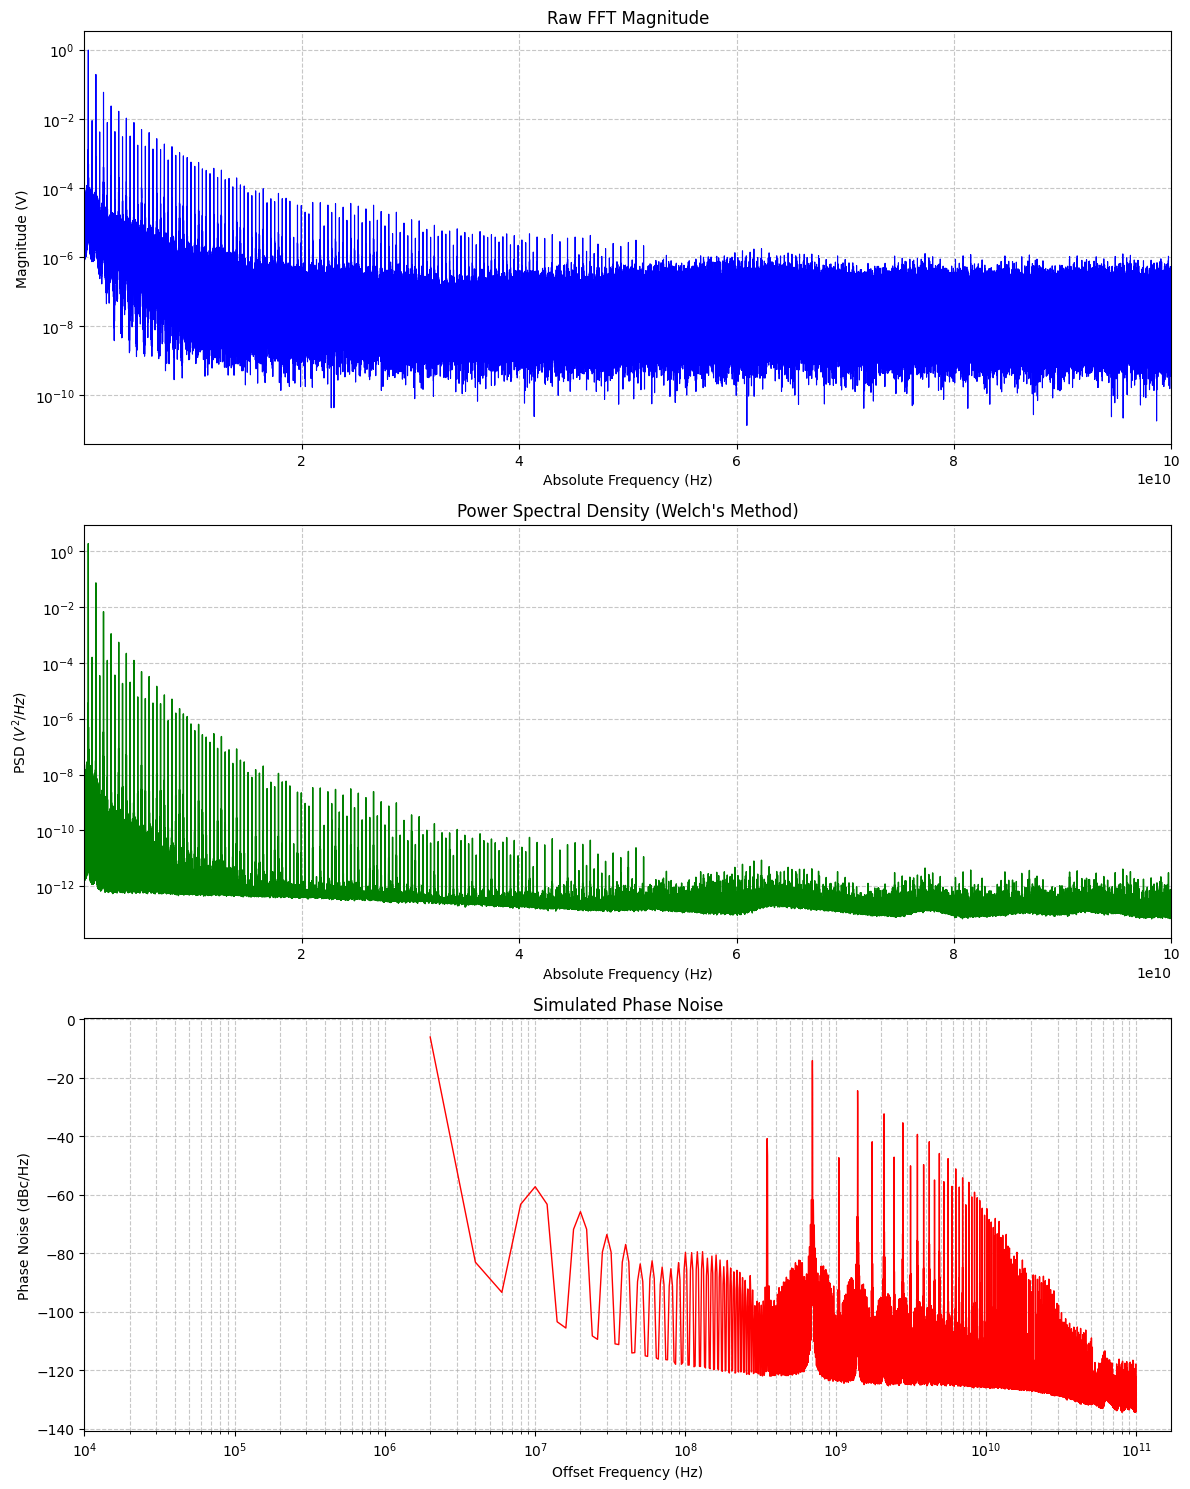

In [4]:
# ==========================================
# 1. Configuration & Data Loading
# ==========================================
FILE_PATH = '../sim_data/tb_PLL_full_N35_350MEG.txt'
# Replace this exactly with the column name of your VCO output in the text file
VCO_COLUMN_NAME = 'phase1' 

print("Loading data... (This may take a moment for large files)")
# Read the space-separated file exported by Ngspice
df = pd.read_csv(FILE_PATH, sep=r'\s+')

# Extract time and voltage arrays
# Slice the data to ONLY include the stable locked region (after 182us)
df = df[df['time'] > 15e-6]

t = df['time'].values
v = df[VCO_COLUMN_NAME].values

# ==========================================
# 2. Jitter Calculation (Time Domain)
# ==========================================
print("Calculating Jitter...")
# Find the mid-point threshold of the waveform
v_mid = (np.max(v) + np.min(v)) / 2.0

# Find indices where the voltage crosses the threshold (Rising Edges)
crossings = np.where((v[:-1] < v_mid) & (v[1:] >= v_mid))[0]

edge_times = []
# Interpolate exact crossing times to remove SPICE discrete-time quantization errors
for idx in crossings:
    t1, t2 = t[idx], t[idx+1]
    v1, v2 = v[idx], v[idx+1]
    # Linear interpolation: t_cross = t1 + (t2 - t1) * (v_mid - v1) / (v2 - v1)
    t_cross = t1 + (t2 - t1) * (v_mid - v1) / (v2 - v1)
    edge_times.append(t_cross)

edge_times = np.array(edge_times)
# Calculate the period between consecutive rising edges
periods = np.diff(edge_times)

# Calculate Jitter Metrics
mean_period = np.mean(periods)
rms_jitter = np.std(periods)
pk_pk_jitter = np.max(periods) - np.min(periods)

print(f"--- Jitter Results ---")
print(f"Mean Frequency: {1/mean_period / 1e6:.2f} MHz")
print(f"RMS Jitter:     {rms_jitter * 1e12:.2f} ps")
print(f"Pk-Pk Jitter:   {pk_pk_jitter * 1e12:.2f} ps\n")

# ==========================================
# 3. Phase Noise & FFT Calculation (Frequency Domain)
# ==========================================
print("Calculating Frequency Data...")
# SPICE uses variable time steps. An FFT requires a strictly uniform time grid.
dt_uniform = np.median(np.diff(t))
fs = 1.0 / dt_uniform
t_uniform = np.arange(t[0], t[-1], dt_uniform)

# Interpolate the voltage onto the uniform time grid
interpolator = interp1d(t, v, kind='linear')
v_uniform = interpolator(t_uniform)
N = len(v_uniform)

# --- A. Raw FFT Calculation ---
# Calculate the raw 1D discrete Fourier Transform
fft_complex = np.fft.fft(v_uniform)
fft_freqs = np.fft.fftfreq(N, d=dt_uniform)
# Normalize magnitude and extract only positive frequencies
fft_mag = np.abs(fft_complex) / N
pos_fft_idx = fft_freqs > 0
fft_freqs_pos = fft_freqs[pos_fft_idx]
fft_mag_pos = fft_mag[pos_fft_idx]

# --- B. PSD Calculation (Welch's Method) ---
# nperseg defines the frequency resolution. Higher = better resolution but more noise.
nperseg = min(N // 4, 100000) 
frequencies, psd = signal.welch(v_uniform, fs=fs, window='hann', nperseg=nperseg, scaling='spectrum')

# Find the fundamental carrier frequency and its power
carrier_idx = np.argmax(psd)
carrier_freq = frequencies[carrier_idx]
carrier_power = psd[carrier_idx]

# --- C. Phase Noise Calculation ---
# L(f) = 10 * log10( PSD(f) / Carrier_Power )
phase_noise_dBc = 10 * np.log10(psd / carrier_power)

# Calculate offset frequencies (distance from the carrier)
offset_freqs = frequencies - carrier_freq

# Filter for only positive offset frequencies (the right side of the skirt)
valid_indices = offset_freqs > 0
offset_freqs = offset_freqs[valid_indices]
phase_noise_dBc = phase_noise_dBc[valid_indices]

# Extract a benchmark value (e.g., at 1 MHz offset)
target_offset = 1e6 # 1 MHz
closest_idx = np.argmin(np.abs(offset_freqs - target_offset))
print(f"--- Phase Noise Results ---")
print(f"Carrier Freq:   {carrier_freq / 1e6:.2f} MHz")
print(f"Phase Noise @ 1MHz: {phase_noise_dBc[closest_idx]:.2f} dBc/Hz")

# ==========================================
# 4. Plotting
# ==========================================
# Create a figure with 3 subplots stacked vertically
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

# --- Plot 1: Raw FFT Magnitude ---
ax1.semilogy(fft_freqs_pos, fft_mag_pos, color='blue', linewidth=0.8)
ax1.set_title('Raw FFT Magnitude')
ax1.set_xlabel('Absolute Frequency (Hz)')
ax1.set_ylabel('Magnitude (V)')
ax1.grid(True, which="both", ls="--", alpha=0.7)
ax1.set_xlim(left=10e3, right=fs/2) # Show up to Nyquist limit

# --- Plot 2: Power Spectral Density ---
ax2.semilogy(frequencies, psd, color='green', linewidth=1)
ax2.set_title('Power Spectral Density (Welch\'s Method)')
ax2.set_xlabel('Absolute Frequency (Hz)')
ax2.set_ylabel('PSD ($V^2/Hz$)')
ax2.grid(True, which="both", ls="--", alpha=0.7)
ax2.set_xlim(left=10e3, right=fs/2)

# --- Plot 3: Phase Noise ---
ax3.semilogx(offset_freqs, phase_noise_dBc, color='red', linewidth=1)
ax3.set_title('Simulated Phase Noise')
ax3.set_xlabel('Offset Frequency (Hz)')
ax3.set_ylabel('Phase Noise (dBc/Hz)')
ax3.grid(True, which="both", ls="--", alpha=0.7)
ax3.set_xlim(left=10e3) # Start plot at 10 kHz offset

plt.tight_layout()
plt.show()